<a href="https://colab.research.google.com/github/chaturvedulakashyap-source/Exhibition-Inhibitor-Oscillator/blob/main/Excitation_Inhibition_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

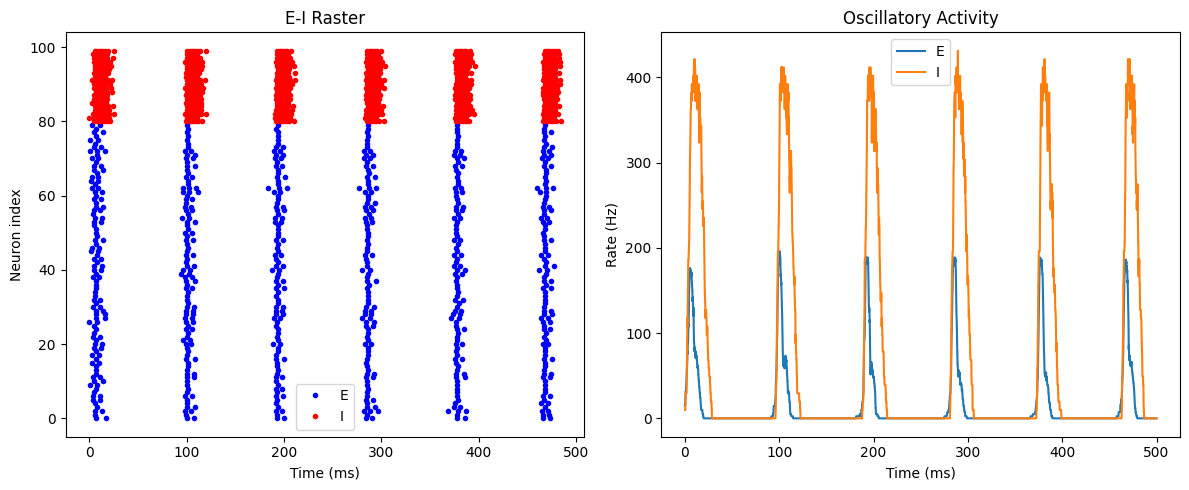

In [5]:
from brian2 import *
import matplotlib.pyplot as plt

start_scope()
defaultclock.dt = 0.1*ms

N_E = 80
N_I = 20

tau_E = 20*ms
tau_I = 10*ms

w_EE = 0.9
w_EI = 0.9
w_IE = 0.6
w_II = 0.3

eqs = '''
dv/dt = (-v + gE - gI + I)/tau + sigma*xi : 1 (unless refractory)
dgE/dt = -gE/(5*ms) : 1
dgI/dt = -gI/(10*ms) : 1
I : 1
tau : second
sigma : 1/second**0.5
'''

E = NeuronGroup(N_E, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='euler')
I = NeuronGroup(N_I, eqs, threshold='v>1', reset='v=0', refractory=2*ms, method='euler')

E.v = 'rand()'
I.v = 'rand()'

E.I = 1.2
I.I = 0.5

E.tau = tau_E
I.tau = tau_I

E.sigma = 0.03/ms**0.5
I.sigma = 0.03/ms**0.5

S_EE = Synapses(E, E, on_pre='gE_post += w_EE')
S_EI = Synapses(E, I, on_pre='gE_post += w_EI')
S_IE = Synapses(I, E, on_pre='gI_post += w_IE')
S_II = Synapses(I, I, on_pre='gI_post += w_II')

S_EE.connect(p=0.4)
S_EI.connect(p=0.5)
S_IE.connect(p=0.5)
S_II.connect(p=0.2)

S_EE.delay = 1.5*ms
S_EI.delay = 1.5*ms
S_IE.delay = 2*ms
S_II.delay = 1.0*ms

spike_E = SpikeMonitor(E)
spike_I = SpikeMonitor(I)
rate_E = PopulationRateMonitor(E)
rate_I = PopulationRateMonitor(I)

run(500*ms)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.plot(spike_E.t/ms, spike_E.i, '.b', label='E')
plt.plot(spike_I.t/ms, spike_I.i + N_E, '.r', label='I')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('E-I Raster')
plt.legend()

plt.subplot(122)
plt.plot(rate_E.t/ms, rate_E.smooth_rate(window='flat', width=5*ms)/Hz, label='E')
plt.plot(rate_I.t/ms, rate_I.smooth_rate(window='flat', width=5*ms)/Hz, label='I')
plt.xlabel('Time (ms)')
plt.ylabel('Rate (Hz)')
plt.title('Oscillatory Activity')
plt.legend()

plt.tight_layout()
plt.show()